In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn import neighbors, svm
from sklearn.cluster import KMeans
from sklearn.decomposition import IncrementalPCA
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import plot_confusion_matrix, fbeta_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import shuffle
from imblearn.ensemble import EasyEnsembleClassifier 
import seaborn as sns

In [2]:
sns.set_style('white')

## Data handling

In [3]:
df  = pd.read_csv('./HeartDiseaseTrain.csv') 

In [4]:
df.head()

,HeartDisease,Sex,GeneralHealth,MentalHealth,PhysicalHealth,AgeGroup,PhysicalActivity,Stroke,SkinCancer,Cancer,...,Smoking,Weight,Height,White,Black,American Indian/Alaskan Native,Asian,Native Hawaiian/Pacific Islander,Other,Hispanic
0,0.0,1.0,2.0,2.0,2.0,8.0,1.0,0.0,0.0,0.0,...,1.0,104.33,1.78,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,2.0,3.0,1.0,3.0,0.0,0.0,0.0,0.0,...,1.0,79.38,1.68,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,3.0,1.0,1.0,13.0,1.0,0.0,0.0,0.0,...,1.0,90.72,1.65,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,3.0,1.0,2.0,8.0,1.0,0.0,0.0,0.0,...,1.0,97.52,1.73,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,3.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,56.70,1.68,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Convert the binary catagorical variables to dummy variables

Split dataset

In [5]:
X = df.iloc[:, 1:]
y = df.iloc[:,0]

x_train, x_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

## Principle component analysis

In [6]:
n_reddim_batches = 100
inc_pca = IncrementalPCA()
for batch_i in np.array_split(x_train, n_reddim_batches):
    inc_pca.partial_fit(batch_i)

In [7]:
pca_sum = np.cumsum(inc_pca.explained_variance_ratio_)

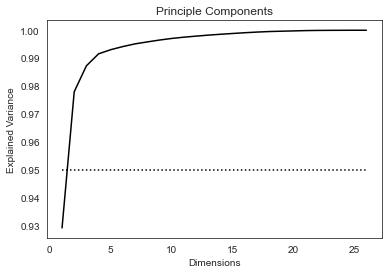

In [8]:
pca_thres = 0.95
tot_components = pca_sum.shape[0]
x_components = np.arange(1,tot_components+1)

plt.figure()
plt.ylabel('Explained Variance')
plt.xlabel('Dimensions')
plt.plot(x_components,pca_sum,color='k')
plt.plot(x_components,np.linspace(pca_thres,pca_thres,tot_components),color='k', linestyle=':')
plt.title('Principle Components')
plt.show()

Choose to conserve over 95% of the variance

In [9]:
n_reddim_batches = 100
n_comp = 2
inc_pca = IncrementalPCA(n_components=n_comp)
for batch_i in np.array_split(x_train, n_reddim_batches):
    inc_pca.partial_fit(batch_i)

Transform data

In [10]:
x_train = inc_pca.transform(x_train)
x_valid = inc_pca.transform(x_valid)

2D reduction allows

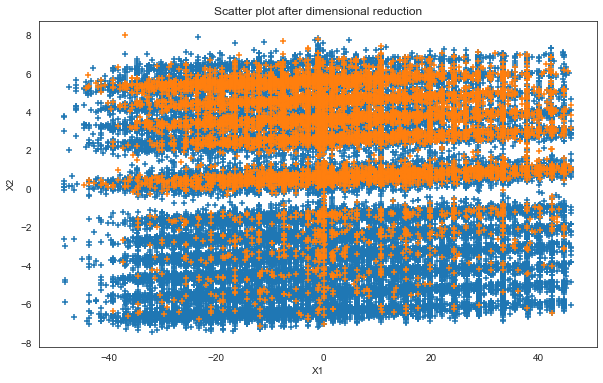

In [11]:
plt.figure(figsize=(10,6))
for i in range(2):
    class_ind = np.where(y_train == i)
    plt.scatter(x_train[class_ind,0],x_train[class_ind,1],marker='+')

plt.title("Scatter plot after dimensional reduction")
plt.ylabel("X2")
plt.xlabel("X1")
plt.show()

## Model selection

In [12]:
beta = 2     # Calculate F2 score

In [13]:
def learning_plot(sample_steps,score_train,score_valid,title):
    plt.figure()
    plt.plot(sample_steps,score_train)
    plt.plot(sample_steps,score_valid)
    plt.xlabel('Number of training samples')
    plt.ylabel('Score')
    plt.legend(['Training','Validation'])
    plt.title(title)
    plt.show()

In [14]:
def fscores_plot(undersampling_ratio,Fb_train,Fb_valid,title): 
    plt.figure()
    plt.plot(undersampling_ratio,Fb_train)
    plt.plot(undersampling_ratio,Fb_valid)

    legend = ['Training','Validation']
    plt.legend(legend)
    plt.xlabel('Undersampling Ratio')
    plt.title(title)
    plt.show()

### Logistic regression classifier

In [15]:
lr = LogisticRegression(max_iter=1000,tol=1e-4)

In [16]:
r_undersample = np.linspace(0.1,1,9)

In [17]:
lr_fscore_train = []
lr_fscore_valid = []

for i in r_undersample:
    rus = RandomUnderSampler(sampling_strategy=i,random_state=42)
    x_res, y_res = rus.fit_resample(x_train,y_train)  
    x_res, y_res = shuffle(x_res, y_res, random_state=42)
    lr.fit(x_res, y_res)
    
    # Compute model F-Score
    lr_fscore_train.append(fbeta_score(y_res,lr.predict(x_res),beta=beta))
    lr_fscore_valid.append(fbeta_score(y_valid,lr.predict(x_valid),beta=beta))   

In [18]:
print('F2 Score training: ' + str(lr_fscore_train[-1]))
print('F2 Score validation: ' + str(lr_fscore_valid[-1]))

F2 Score training: 0.7292504925493244
F2 Score validation: 0.3427682157963342


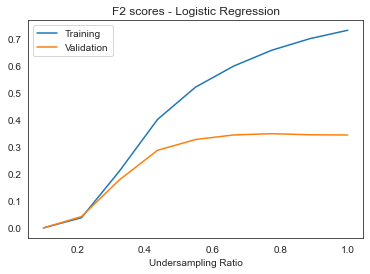

In [19]:
fscores_plot(r_undersample,lr_fscore_train,lr_fscore_valid,'F2 scores - Logistic Regression')

In [20]:
lr_score_train = []
lr_score_valid = []
sample_steps  = np.int_(np.geomspace(1e-1,1,num=10)*x_res.shape[0])
                         
for i in sample_steps:
    lr.fit(x_res[:i],y_res[:i])
    lr_score_train.append(lr.score(x_res[:i],y_res[:i]))
    lr_score_valid.append(lr.score(x_valid,y_valid))

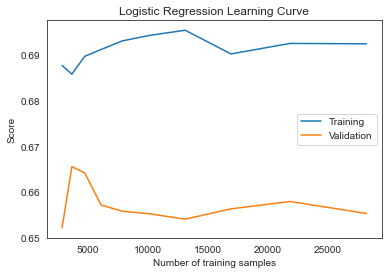

In [21]:
learning_plot(sample_steps,lr_score_train,lr_score_valid,'Logistic Regression Learning Curve')

### K Nearest Neighbor

In [22]:
knn = neighbors.KNeighborsClassifier()

In [23]:
knn_fscore_train = []
knn_fscore_valid = []

for i in r_undersample:
    rus = RandomUnderSampler(sampling_strategy=i,random_state=42)
    x_res, y_res = rus.fit_resample(x_train,y_train)  
    x_res, y_res = shuffle(x_res, y_res, random_state=42)
    knn.fit(x_res, y_res)
    
    # Compute model F-Score
    knn_fscore_train.append(fbeta_score(y_res,knn.predict(x_res),beta=beta))
    knn_fscore_valid.append(fbeta_score(y_valid,knn.predict(x_valid),beta=beta))   

In [24]:
print('F2 Score training: ' + str(knn_fscore_train[-1]))
print('F2 Score validation: ' + str(knn_fscore_valid[-1]))

F2 Score training: 0.8022272778339512
F2 Score validation: 0.3466328667474926


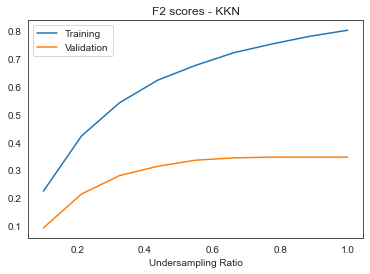

In [25]:
fscores_plot(r_undersample,knn_fscore_train,knn_fscore_valid,'F2 scores - KKN')

In [26]:
knn_score_train = []
knn_score_valid = []
sample_steps  = np.int_(np.geomspace(1e-1,1,num=10)*x_res.shape[0])
                         
for i in sample_steps:
    knn.fit(x_res[:i],y_res[:i])
    knn_score_train.append(knn.score(x_res[:i],y_res[:i]))
    knn_score_valid.append(knn.score(x_valid,y_valid))

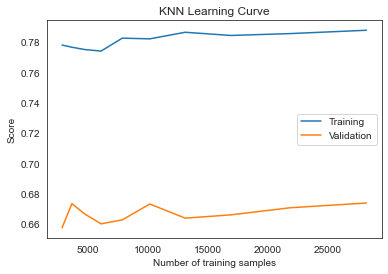

In [27]:
learning_plot(sample_steps,knn_score_train,knn_score_valid,'KNN Learning Curve')

### Random forest

In [28]:
rforest = RandomForestClassifier(criterion="entropy")

In [29]:
rforest_fscore_train = []
rforest_fscore_valid = []

for i in r_undersample:
    rus = RandomUnderSampler(sampling_strategy=i,random_state=42)
    x_res, y_res = rus.fit_resample(x_train,y_train)  
    x_res, y_res = shuffle(x_res, y_res, random_state=42)
    rforest.fit(x_res, y_res)
    
    # Compute model F-Score
    rforest_fscore_train.append(fbeta_score(y_res,rforest.predict(x_res),beta=beta))
    rforest_fscore_valid.append(fbeta_score(y_valid,rforest.predict(x_valid),beta=beta))   

In [30]:
print('F2 Score training: ' + str(rforest_fscore_train[-1]))
print('F2 Score validation: ' + str(rforest_fscore_valid[-1]))

F2 Score training: 0.997832646296375
F2 Score validation: 0.3454915859682416


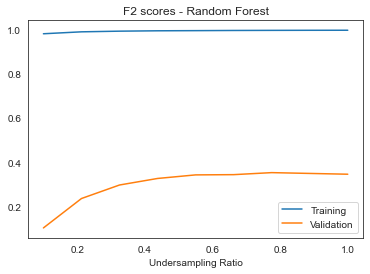

In [31]:
fscores_plot(r_undersample,rforest_fscore_train,rforest_fscore_valid,'F2 scores - Random Forest')

In [32]:
rforest_score_train = []
rforest_score_valid = []
sample_steps  = np.int_(np.geomspace(1e-1,1,num=10)*x_res.shape[0])
                         
for i in sample_steps:
    rforest.fit(x_res[:i],y_res[:i])
    rforest_score_train.append(rforest.score(x_res[:i],y_res[:i]))
    rforest_score_valid.append(rforest.score(x_valid,y_valid))

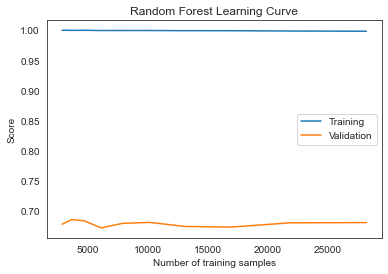

In [33]:
learning_plot(sample_steps,rforest_score_train,rforest_score_valid,'Random Forest Learning Curve')

### Naive Bayes

In [34]:
nb = GaussianNB()

In [35]:
nb_fscore_train = []
nb_fscore_valid = []

for i in r_undersample:
    rus = RandomUnderSampler(sampling_strategy=i,random_state=42)
    x_res, y_res = rus.fit_resample(x_train,y_train)  
    x_res, y_res = shuffle(x_res, y_res, random_state=42)
    nb.fit(x_res, y_res)
    
    # Compute model F-Score
    nb_fscore_train.append(fbeta_score(y_res,nb.predict(x_res),beta=beta))
    nb_fscore_valid.append(fbeta_score(y_valid,nb.predict(x_valid),beta=beta))   

In [36]:
print('F2 Score training: ' + str(nb_fscore_train[-1]))
print('F2 Score validation: ' + str(nb_fscore_valid[-1]))

F2 Score training: 0.7781720546170867
F2 Score validation: 0.33480874834311686


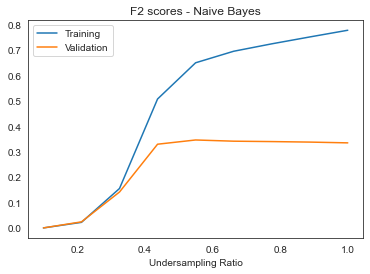

In [37]:
fscores_plot(r_undersample,nb_fscore_train,nb_fscore_valid,'F2 scores - Naive Bayes')

In [38]:
nb_score_train = []
nb_score_valid = []
nb_iteration_score = []
sample_steps  = np.int_(np.geomspace(1e-1,1,num=10)*x_res.shape[0])
                         
for i in sample_steps:
    nb.fit(x_res[:i],y_res[:i])
    nb_score_train.append(nb.score(x_res[:i],y_res[:i]))
    nb_score_valid.append(nb.score(x_valid,y_valid))

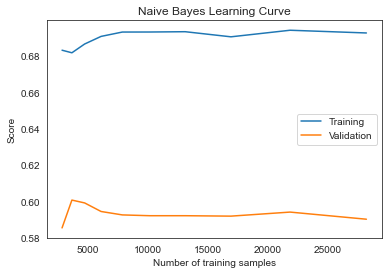

In [39]:
learning_plot(sample_steps,nb_score_train,nb_score_valid,'Naive Bayes Learning Curve')

### MLP Classifier

In [40]:
n_net = MLPClassifier(max_iter = 1000)

In [41]:
n_net_fscore_train = []
n_net_fscore_valid = []

for i in r_undersample:
    rus = RandomUnderSampler(sampling_strategy=i,random_state=42)
    x_res, y_res = rus.fit_resample(x_train,y_train)  
    x_res, y_res = shuffle(x_res, y_res, random_state=42)
    n_net.fit(x_res, y_res)
    
    # Compute model F-Score
    n_net_fscore_train.append(fbeta_score(y_res,n_net.predict(x_res),beta=beta))
    n_net_fscore_valid.append(fbeta_score(y_valid,n_net.predict(x_valid),beta=beta))   

In [42]:
print('F2 Score training: ' + str(n_net_fscore_train[-1]))
print('F2 Score validation: ' + str(n_net_fscore_valid[-1]))

F2 Score training: 0.7539873009777973
F2 Score validation: 0.34481884333561524


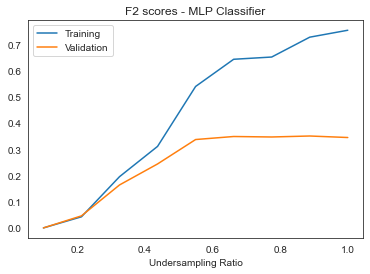

In [43]:
fscores_plot(r_undersample,n_net_fscore_train,n_net_fscore_valid,'F2 scores - MLP Classifier')

In [44]:
n_net_score_train = []
n_net_score_valid = []
n_net_iteration_score = []
sample_steps  = np.int_(np.geomspace(1e-1,1,num=10)*x_res.shape[0])
                         
for i in sample_steps:
    n_net.fit(x_res[:i],y_res[:i])
    n_net_score_train.append(n_net.score(x_res[:i],y_res[:i]))
    n_net_score_valid.append(n_net.score(x_valid,y_valid))

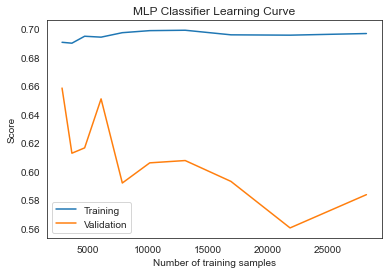

In [45]:
learning_plot(sample_steps,n_net_score_train,n_net_score_valid,'MLP Classifier Learning Curve')

### Ensemble classifier

In [46]:
eec = EasyEnsembleClassifier(random_state=42)

In [47]:
eec_fscore_train = []
eec_fscore_valid = []

for i in r_undersample:
    rus = RandomUnderSampler(sampling_strategy=i,random_state=42)
    x_res, y_res = rus.fit_resample(x_train,y_train)  
    x_res, y_res = shuffle(x_res, y_res, random_state=42)
    eec.fit(x_res, y_res)
    
    # Compute model F-Score
    eec_fscore_train.append(fbeta_score(y_res,eec.predict(x_res),beta=beta))
    eec_fscore_valid.append(fbeta_score(y_valid,eec.predict(x_valid),beta=beta))   

In [48]:
print('F2 Score training: ' + str(eec_fscore_train[-1]))
print('F2 Score validation: ' + str(eec_fscore_valid[-1]))

F2 Score training: 0.7777611574968044
F2 Score validation: 0.3484190948543087


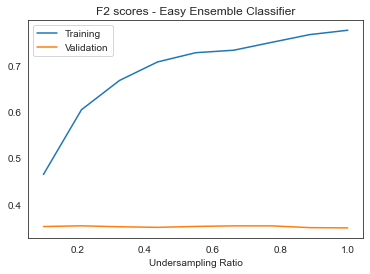

In [49]:
fscores_plot(r_undersample,eec_fscore_train,eec_fscore_valid,'F2 scores - Easy Ensemble Classifier')

In [50]:
eec_score_train = []
eec_score_valid = []
eec_iteration_score = []
sample_steps  = np.int_(np.geomspace(1e-1,1,num=10)*x_res.shape[0])
                         
for i in sample_steps:
    eec.fit(x_res[:i],y_res[:i])
    eec_score_train.append(eec.score(x_res[:i],y_res[:i]))
    eec_score_valid.append(eec.score(x_valid,y_valid))

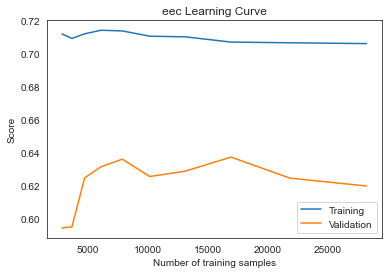

In [51]:
learning_plot(sample_steps,eec_score_train,eec_score_valid,'eec Learning Curve')

## Plots

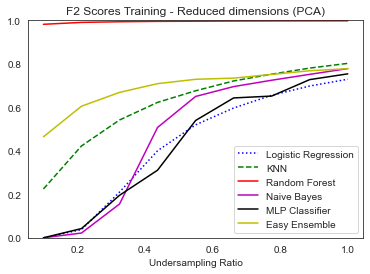

In [52]:
plt.figure()
plt.plot(r_undersample,lr_fscore_train,linestyle=':',color='b')
plt.plot(r_undersample,knn_fscore_train,linestyle='--',color='g')
plt.plot(r_undersample,rforest_fscore_train,linestyle='-',color='r')
plt.plot(r_undersample,nb_fscore_train,linestyle='-',color='m')
plt.plot(r_undersample,n_net_fscore_train,linestyle='-',color='k')
plt.plot(r_undersample,eec_fscore_train,linestyle='-',color='y')

legend = ['Logistic Regression','KNN','Random Forest','Naive Bayes','MLP Classifier','Easy Ensemble']
plt.legend(legend)
plt.xlabel('Undersampling Ratio')
plt.title('F2 Scores Training - Reduced dimensions (PCA)')
plt.ylim(0,1)
plt.show()

Training data has been undersampled

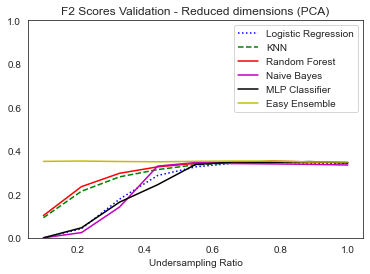

In [53]:
plt.figure()
plt.plot(r_undersample,lr_fscore_valid,linestyle=':',color='b')
plt.plot(r_undersample,knn_fscore_valid,linestyle='--',color='g')
plt.plot(r_undersample,rforest_fscore_valid,linestyle='-',color='r')
plt.plot(r_undersample,nb_fscore_valid,linestyle='-',color='m')
plt.plot(r_undersample,n_net_fscore_valid,linestyle='-',color='k')
plt.plot(r_undersample,eec_fscore_valid,linestyle='-',color='y')

legend = ['Logistic Regression','KNN','Random Forest','Naive Bayes','MLP Classifier','Easy Ensemble']
plt.legend(legend)
plt.xlabel('Undersampling Ratio')
plt.title('F2 Scores Validation - Reduced dimensions (PCA)')
plt.ylim(0,1)
plt.show()